# TECH 405 Hackathon — Digits Classification with LSTM

## Final combined implementation

### Hackathon setup
- Dataset: **Digits (scikit-learn)**
- Classes: **10**
- Fixed split: **80% train / 20% test**
- Input: **8 time steps × 8 features**
- Model: **LSTM → Linear**
- Baseline: **majority class on the test set**
- Target: **93% test accuracy**
- No pretrained model
- No external dataset download

In [2]:
%pip install -q torch scikit-learn numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [3]:
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("PyTorch version:", torch.__version__)
print("Device:", "cuda" if torch.cuda.is_available() else "cpu")

PyTorch version: 2.14.1+cpu
Device: cpu


## 2. Reproducibility and device

In [4]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

Using: cpu


## 3. Load the built-in Digits dataset

No CSV, ZIP file, or internet download is required.

`load_digits()` supplies the images and labels directly from scikit-learn.

In [5]:
digits = load_digits()

X = digits.images.astype(np.float32)
y = digits.target.astype(np.int64)

print("Raw X shape:", X.shape)
print("Raw y shape:", y.shape)
print("Classes:", np.unique(y))
print("Raw pixel range:", X.min(), "to", X.max())

Raw X shape: (1797, 8, 8)
Raw y shape: (1797,)
Classes: [0 1 2 3 4 5 6 7 8 9]
Raw pixel range: 0.0 to 16.0


## 4. Visualize the dataset

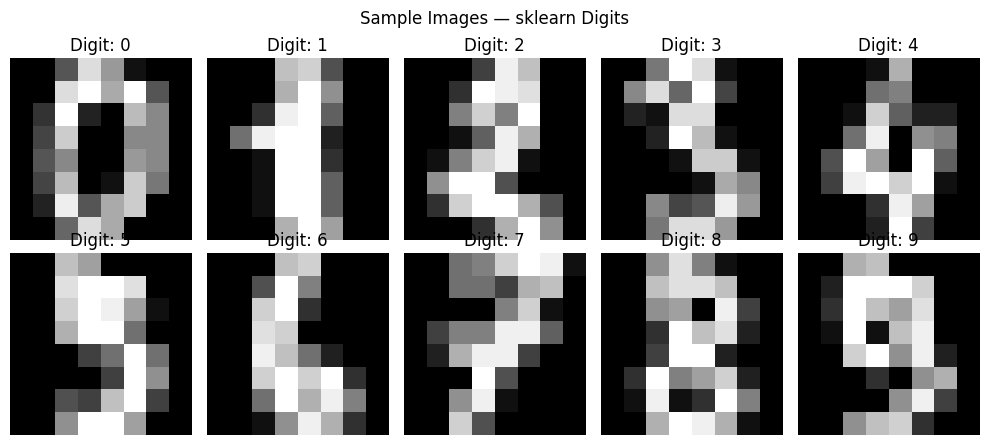

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4.5))

for ax, image, label in zip(axes.ravel(), X[:10], y[:10]):
    ax.imshow(image, cmap="gray")
    ax.set_title(f"Digit: {label}")
    ax.axis("off")

plt.suptitle("Sample Images — sklearn Digits")
plt.tight_layout()
plt.show()

## 5. Normalize the pixels

The original Digits pixels range from 0 to 16.

Dividing by 16 scales them to approximately 0–1, which makes neural-network training easier.

In [7]:
X = X / 16.0

print("Normalized pixel range:", X.min(), "to", X.max())
print("Shape remains:", X.shape)

Normalized pixel range: 0.0 to 1.0
Shape remains: (1797, 8, 8)


## 6. Create the required fixed 80/20 split

The test set is kept completely separate from model training.

`stratify=y` keeps the ten digit classes represented proportionally.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test: ", X_test.shape)
print("y_test: ", y_test.shape)

print("\nEach sample:", X_train.shape[1], "time steps ×", X_train.shape[2], "features")

X_train: (1437, 8, 8)
y_train: (1437,)
X_test:  (360, 8, 8)
y_test:  (360,)

Each sample: 8 time steps × 8 features


## 7. Calculate the actual majority-class baseline

In [9]:
class_counts = np.bincount(y_test)
baseline = class_counts.max() / len(y_test)

print("Test class counts:", class_counts)
print(f"Majority-class baseline: {baseline * 100:.2f}%")

Test class counts: [36 36 35 37 36 37 36 36 35 36]
Majority-class baseline: 10.28%


## 8. Convert to PyTorch tensors and DataLoaders

In [10]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

sample_X, sample_y = next(iter(train_loader))

print("Batch X shape:", sample_X.shape)
print("Batch y shape:", sample_y.shape)

Batch X shape: torch.Size([64, 8, 8])
Batch y shape: torch.Size([64])


## 9. Define the LSTM model

Architecture:

`8 input features → LSTM(128) → Linear(10)`

The output contains one logit for each digit class 0–9.

In [11]:
class DigitLSTM(nn.Module):
    def __init__(self, input_size=8, hidden_size=128, num_classes=10):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # x shape: (batch, 8 time steps, 8 features)
        output, (hidden, cell) = self.lstm(x)

        # Use the final hidden state for classification.
        last_hidden = hidden[-1]

        return self.fc(last_hidden)


model = DigitLSTM().to(device)

print(model)

DigitLSTM(
  (lstm): LSTM(8, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=10, bias=True)
)


## 10. Loss function and optimizer

We use:

- `CrossEntropyLoss` for 10-class classification
- `Adam` for optimization
- learning rate = `0.003`
- 60 training epochs

In [12]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.003
)

EPOCHS = 60
GRAD_CLIP = 1.0

print("Epochs:", EPOCHS)
print("Learning rate:", 0.003)
print("Gradient clipping:", GRAD_CLIP)

Epochs: 60
Learning rate: 0.003
Gradient clipping: 1.0


## 11. Train the model

In [13]:
train_losses = []

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        logits = model(X_batch)
        loss = criterion(logits, y_batch)

        loss.backward()

        nn.utils.clip_grad_norm_(
            model.parameters(),
            GRAD_CLIP
        )

        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)

    if epoch == 1 or epoch % 10 == 0:
        print(
            f"Epoch {epoch:02d}/{EPOCHS} "
            f"| Training loss: {epoch_loss:.4f}"
        )

Epoch 01/60 | Training loss: 2.1450
Epoch 10/60 | Training loss: 0.1989
Epoch 20/60 | Training loss: 0.0426
Epoch 30/60 | Training loss: 0.0286
Epoch 40/60 | Training loss: 0.0011
Epoch 50/60 | Training loss: 0.0006
Epoch 60/60 | Training loss: 0.0004


## 12. Plot training loss

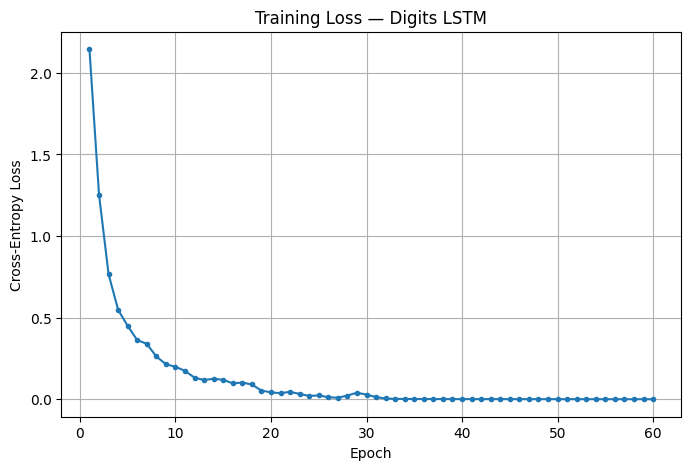

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, EPOCHS + 1),
    train_losses,
    marker="o",
    markersize=3
)

plt.title("Training Loss — Digits LSTM")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.grid(True)
plt.show()

## 13. Final test evaluation

In [15]:
model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)

        logits = model(X_batch)
        predictions = torch.argmax(logits, dim=1)

        all_predictions.extend(
            predictions.cpu().numpy()
        )
        all_labels.extend(
            y_batch.numpy()
        )

test_accuracy = accuracy_score(
    all_labels,
    all_predictions
)

print(f"FINAL TEST ACCURACY: {test_accuracy * 100:.2f}%")
print(f"Majority baseline:   {baseline * 100:.2f}%")
print("Target:               93.00%")

FINAL TEST ACCURACY: 98.89%
Majority baseline:   10.28%
Target:               93.00%


## 14. Check whether the target was genuinely reached

In [16]:
TARGET = 0.93

if test_accuracy >= TARGET:
    print(
        f"✓ Target reached: {test_accuracy * 100:.2f}% >= 93%"
    )
else:
    print(
        f"✗ Target not reached: {test_accuracy * 100:.2f}% < 93%"
    )

✓ Target reached: 98.89% >= 93%


## 15. Classification report

In [17]:
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=[str(i) for i in range(10)],
        digits=4
    )
)

              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        36
           1     1.0000    0.9444    0.9714        36
           2     0.9722    1.0000    0.9859        35
           3     1.0000    1.0000    1.0000        37
           4     0.9730    1.0000    0.9863        36
           5     0.9737    1.0000    0.9867        37
           6     1.0000    0.9722    0.9859        36
           7     1.0000    1.0000    1.0000        36
           8     0.9714    0.9714    0.9714        35
           9     1.0000    1.0000    1.0000        36

    accuracy                         0.9889       360
   macro avg     0.9890    0.9888    0.9888       360
weighted avg     0.9891    0.9889    0.9888       360



## 16. Confusion matrix

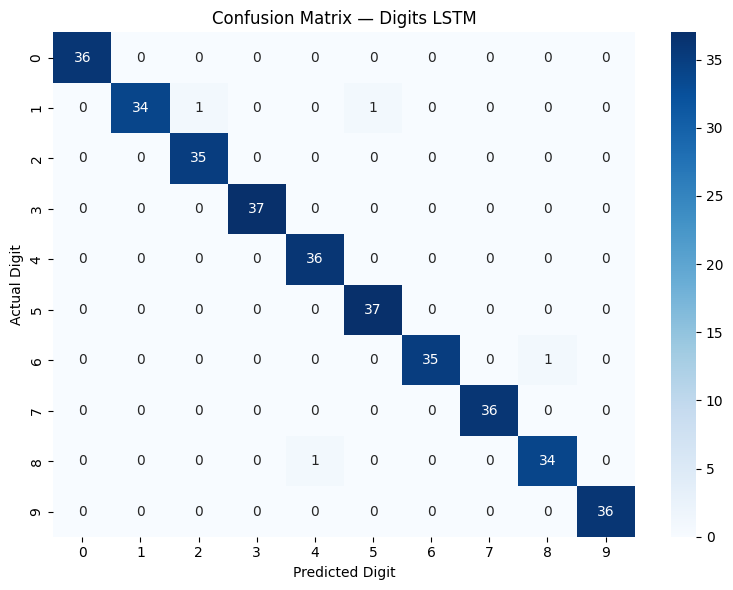

In [18]:
cm = confusion_matrix(
    all_labels,
    all_predictions
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=range(10),
    yticklabels=range(10)
)

plt.title("Confusion Matrix — Digits LSTM")
plt.xlabel("Predicted Digit")
plt.ylabel("Actual Digit")
plt.tight_layout()
plt.show()

## 17. Visualize actual vs predicted digits

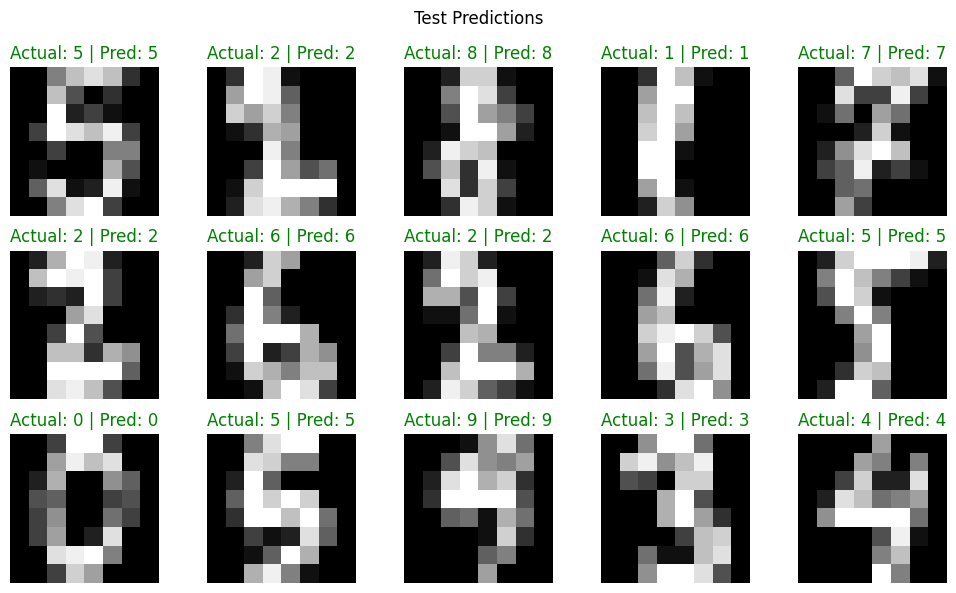

In [19]:
sample_images = X_test[:15]
sample_actual = y_test[:15]

with torch.no_grad():
    sample_tensor = torch.tensor(
        sample_images,
        dtype=torch.float32
    ).to(device)

    sample_logits = model(sample_tensor)
    sample_pred = torch.argmax(
        sample_logits,
        dim=1
    ).cpu().numpy()

fig, axes = plt.subplots(3, 5, figsize=(10, 6))

for ax, image, actual, predicted in zip(
    axes.ravel(),
    sample_images,
    sample_actual,
    sample_pred
):
    ax.imshow(image, cmap="gray")
    ax.set_title(
        f"Actual: {actual} | Pred: {predicted}",
        color="green" if actual == predicted else "red"
    )
    ax.axis("off")

plt.suptitle("Test Predictions")
plt.tight_layout()
plt.show()

## 18. Final comparison

In [20]:
print("=" * 50)
print("DIGITS LSTM — FINAL RESULT")
print("=" * 50)
print(f"Training samples : {len(X_train)}")
print(f"Test samples     : {len(X_test)}")
print(f"Baseline         : {baseline * 100:.2f}%")
print(f"Target           : 93.00%")
print(f"Test accuracy    : {test_accuracy * 100:.2f}%")
print("=" * 50)

DIGITS LSTM — FINAL RESULT
Training samples : 1437
Test samples     : 360
Baseline         : 10.28%
Target           : 93.00%
Test accuracy    : 98.89%
